# AG-HYPOPT · Trial 12

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Eleven trials. Best: **trial_11** `cvm_fwhm` **0.0760** (sw 0.1956), then trial_06 `cvm_fwhm` 0.0764 (sw
0.2074); the same family is bracketed at sw 0.1816 (0.0791) and 0.2345 (0.0777), so its optimum is a flat
basin near sw ~0.20. Against the KDE control (0.080328) that is a genuine ~0.004 improvement, driven by
better gamma (best campaign gamma RMSE 2.28 / rel 23.6 %). The other families at low sw fall short:
`w1_2d` 0.0849, `energy_2d` 0.1021, `mmd_2d` (high sw only) 0.1833. The one untested cell in the map is
`w1_fwhm` at low sw. No divergences. Phase `trials` (11/5), EI-guided.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_12'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (11/5 trials)
ID |     ei | params
 1 | 1.2607 | {"loss_family": "energy_2d", "sigma_weight": 0.2441234194917646}
 2 | 1.1052 | {"loss_family": "w1_2d", "sigma_weight": 0.18007707755480634}
 3 | 2.7966 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.8963093737046804}
 4 | 0.7079 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.5414661617187942}
 5 | 1.7791 | {"loss_family": "kde", "sigma_weight": 0.18392732597749906}
 6 | 2.3964 | {"loss_family": "w1_fwhm", "sigma_weight": 0.20786179267449936}
 7 | 0.5170 | {"loss_family": "energy_2d", "sigma_weight": 0.6705104740545001}
 8 | 3.1936 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.23302240097708438}
 9 |      - | {"loss_family": "w1_2d", "sigma_weight": 0.9366961249291337}
10 |      - | {"loss_family": "kde", "sigma_weight": 0.6492403690544754}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

EI keeps pushing `cvm_fwhm`, now at sw 0.2330 (candidate 8, ei 3.19) - but that value is already bracketed
by trials 05/11 and would just re-confirm ~0.076-0.078. The remaining genuinely unmeasured point in the
family map is `w1_fwhm` at low sw: `w1_fwhm` was 0.0908 at sw 0.5113, and its two-channel twin `w1_2d`
gained ~0.005 by moving to sw 0.209 (trial_10). Running `w1_fwhm` at low sw (candidate 6, sw 0.2079)
closes that gap and checks whether the sigma link changes anything at low sw, exactly as trials 01/04
compared it at high sw. (Candidates 9/10 have no ei; candidate 5 `kde` at sw 0.1839 would just extend the
KDE low-sw series, which trial_07 already showed is not the source of the gain.)

I choose candidate 6.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 6             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'w1_fwhm', 'sigma_weight': 0.20786179267449936}
Running  1nW Trans05 ... 

μ 9.39 -> 5.68 | γ 8.5 -> 2.65 | NLL 16.83


Running  1nW Trans20 ... 

μ 17.32 -> 26.14 | γ 8.5 -> 5.73 | NLL 3.76


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 60.99 | γ 14.1 -> 14.35 | NLL 1.22


Running 3nW Trans100 ... 

μ 175.71 -> 97.62 | γ 14.1 -> 13.76 | NLL 1.60



Total: 7.8 min


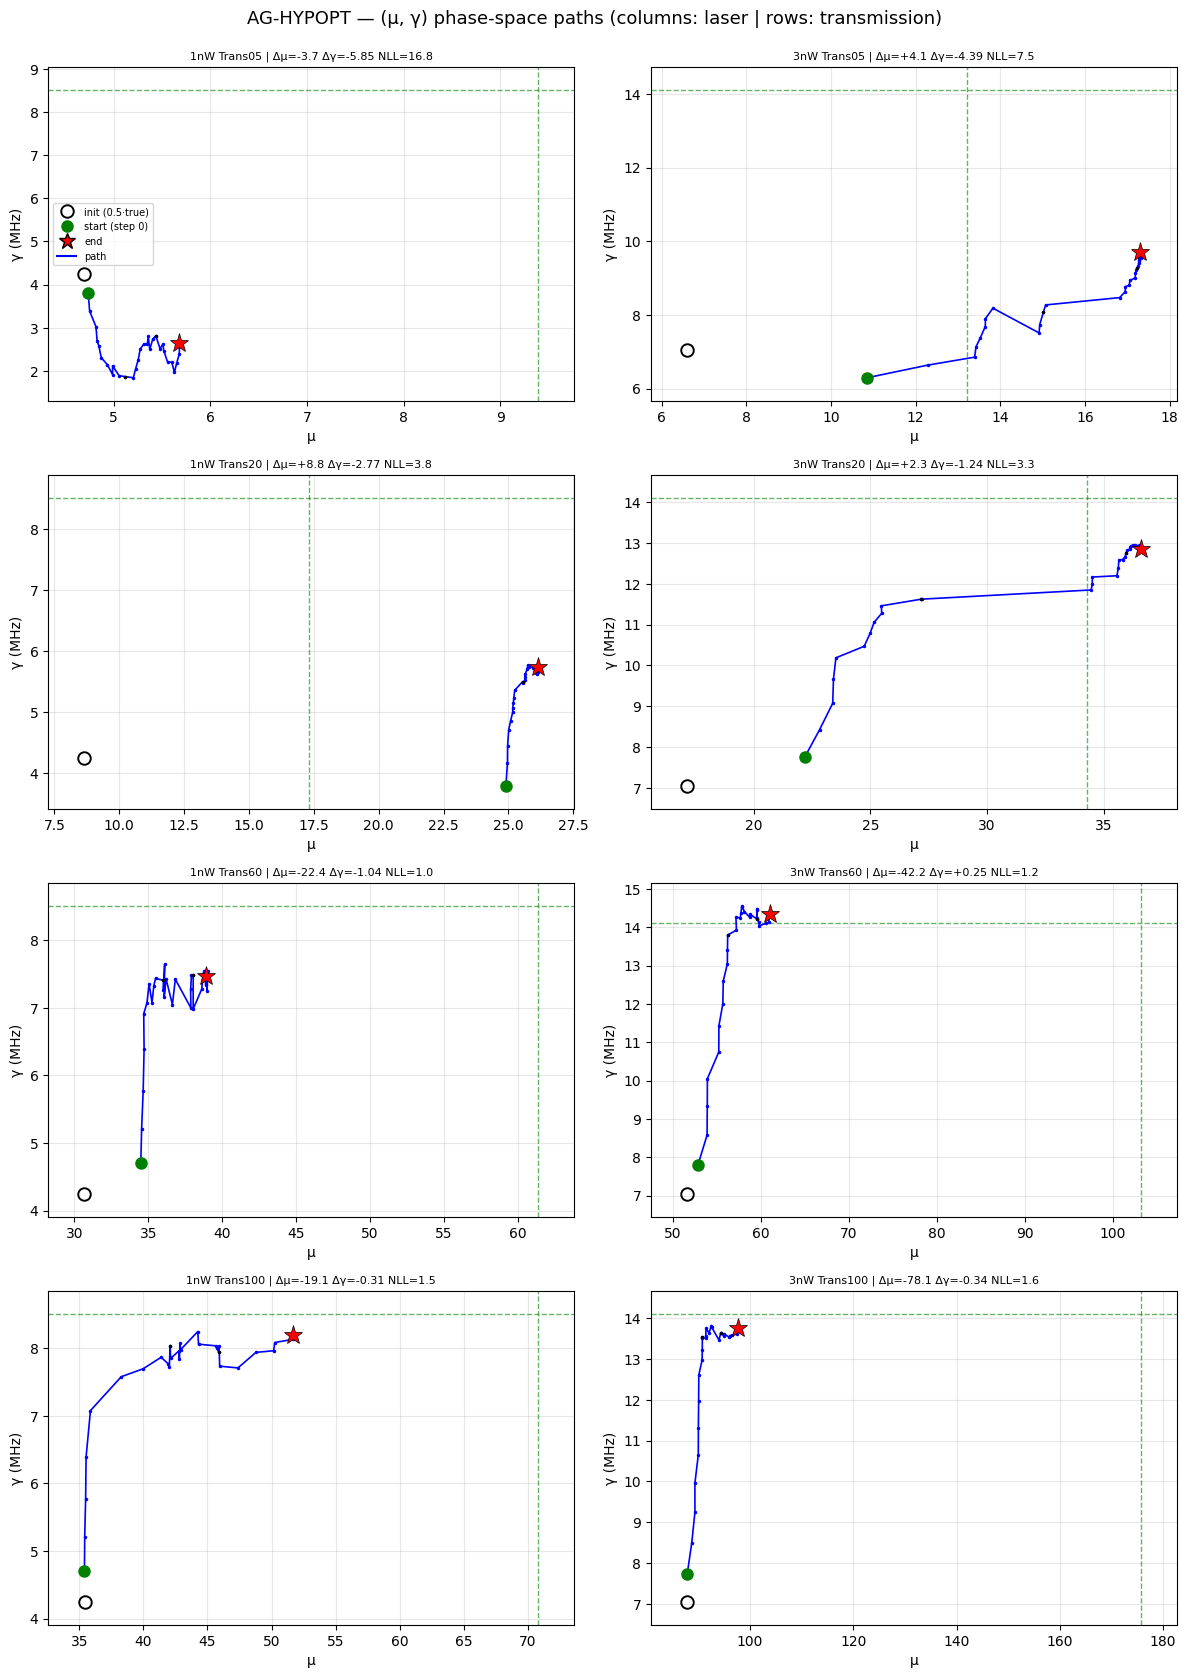

trial finished in 7.8 min
objective = 0.0923 ± 0.0314
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.68   -39.5 |     8.50    2.65   -68.9
1nW Trans20       17.32   26.14   +50.9 |     8.50    5.73   -32.6
1nW Trans60       61.37   38.92   -36.6 |     8.50    7.46   -12.2
1nW Trans100       70.82   51.70   -27.0 |     8.50    8.19    -3.6
3nW Trans05       13.20   17.30   +31.1 |    14.10    9.71   -31.2
3nW Trans20       34.28   36.60    +6.8 |    14.10   12.86    -8.8
3nW Trans60      103.20   60.99   -40.9 |    14.10   14.35    +1.8
3nW Trans100      175.71   97.62   -44.4 |    14.10   13.76    -2.4

weighted objective (T-graded, cap=1.0) = 0.0923 | diverged cells: 0
μ: RMSE 33.285 (rel 36.9%, bias -18.792) | γ: RMSE 2.832 (rel 29.6%, bias -1.962)


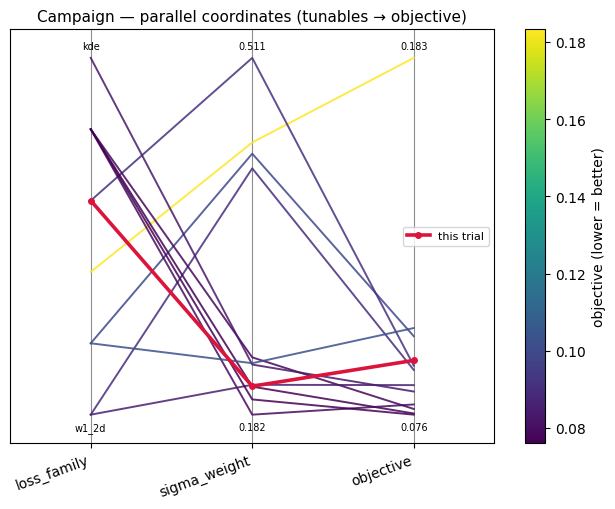

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'w1_fwhm', sigma_weight: 0.2079}` (candidate 6). Trial
time 7.8 min, objective **0.0923 +/- 0.0314**, **0 diverged cells**. That is essentially the same as
`w1_fwhm` at high sw (0.0908 at sw 0.5113) - slightly *worse* - so the FWHM-only W1 loss does not
benefit from the low-sw region. This completes the low-sw family map.

**Per-cell behaviour.**

- 1nW Trans05: mu -39.5 %, gamma 8.5 -> 2.65 (-68.9 %) - a low-count gamma collapse, unlike `cvm_fwhm`
  (-50 %) and even `w1_2d` at low sw (-61 %).
- 1nW Trans20: mu +50.9 %, gamma -32.6 %.
- 1nW Trans60 / Trans100: mu -36.6 % / -27.0 %, gamma -12.2 % / -3.6 %.
- 3nW Trans05 / Trans20: mu +31.1 % / +6.8 %, gamma -31.2 % / -8.8 %.
- 3nW Trans60 / Trans100: mu -40.9 % / -44.4 %, gamma +1.8 % / -2.4 %.

**Aggregates.** mu: RMSE 33.29 (rel 36.9 %), bias -18.79; gamma: RMSE 2.83 (rel 29.6 %), bias -1.96.

**The completed low-sw map (all at sw ~0.18-0.24).** `cvm_fwhm` 0.0760-0.0777 (best), `w1_2d` 0.0849,
`kde` 0.0830, `w1_fwhm` 0.0923, `energy_2d` 0.1021. So at the winning sw only `cvm_fwhm` beats the KDE
control (0.080328); the sigma link helps `w1_2d` but not `w1_fwhm` at low sw.

**Summary:** `w1_fwhm` at sw 0.2079 gives objective 0.0923, no better than its high-sw value (0.0908),
completing the low-sw map with `cvm_fwhm` as the sole family under the KDE control.
**Key insight:** The FWHM-only W1 loss gains nothing from the low-sw region (0.0923 vs 0.0908), whereas its
two-channel twin `w1_2d` does (0.0849) - the sigma link only pays off at low sw.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'w1_fwhm at sigma_weight 0.2079 gives objective 0.0923, no better than its high-sw value (0.0908), completing the low-sw map with cvm_fwhm as the sole family under the KDE control.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'The FWHM-only W1 loss gains nothing from the low-sw region (0.0923 vs 0.0908), whereas its two-channel twin w1_2d does (0.0849) - the sigma link only pays off at low sw.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_12 | current best: trial_11


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_13.ipynb. Open it and follow its cells from the top.
